# T1 — Tuning Logistic Regression
GridSearchCV trên `t1_train.csv` | cv=5 | scoring=accuracy

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score

ROOT = Path('../../')
train = pd.read_csv(ROOT / 'data/processed/t1_train.csv')
X_train = train.drop(columns=['winner'])
y_train = train['winner']

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 110
C1, C2 = '#4C82C2', '#E07B54'

print(f'{X_train.shape}')

(40236, 58)


In [12]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'model__C':      [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'saga'],
}

gs = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print(f'Best params : {gs.best_params_}')
print(f'Best CV Acc : {gs.best_score_:.4f} ({gs.best_score_*100:.2f}%)')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'model__C': 0.001, 'model__solver': 'lbfgs'}
Best CV Acc : 0.5180 (51.80%)


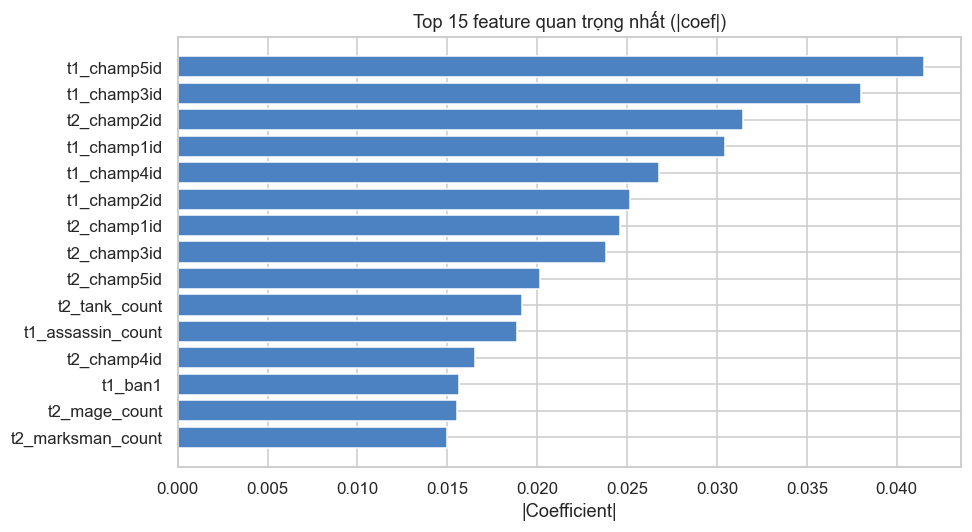

In [4]:
# Coefficients của best model (absolute value = importance)
best_model = gs.best_estimator_.named_steps['model']
coef = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns)
top15_coef = coef.nlargest(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15_coef.index[::-1], top15_coef.values[::-1], color=C1)
ax.set_xlabel('|Coefficient|')
ax.set_title('Top 15 feature quan trọng nhất (|coef|)')
plt.tight_layout()
plt.show()

In [14]:
print('=' * 55)
print('KET QUA - LOGISTIC REGRESSION')
print('=' * 55)
print(f'Best CV Accuracy : {gs.best_score_:.4f}  ({gs.best_score_*100:.2f}%)')
print(f'Best params      : {gs.best_params_}')
print()
print('=> Dung cho t1_train_best.py:')
print(f"BEST_MODEL  = 'lr'")
print(f"BEST_PARAMS = {{")
print(f"    'C'          : {gs.best_params_['model__C']},")
print(f"    'solver'     : '{gs.best_params_['model__solver']}',")
print(f"    'max_iter'   : 1000,")
print(f"    'random_state': 42,")
print(f"}}") 

KET QUA - LOGISTIC REGRESSION
Best CV Accuracy : 0.5180  (51.80%)
Best params      : {'model__C': 0.001, 'model__solver': 'lbfgs'}

=> Dung cho t1_train_best.py:
BEST_MODEL  = 'lr'
BEST_PARAMS = {
    'C'          : 0.001,
    'solver'     : 'lbfgs',
    'max_iter'   : 1000,
    'random_state': 42,
}
